In [16]:
BaselineTraining = True
LogisticRegression = False
RandomForest = True

PolynomialFeaturesTesting = False
DomainFeaturesTesting = True

# 2. Data Preprocessing

In [31]:
import pandas as pd
import numpy as np
import os, sys
import gc
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2.1 Data Overview

In this study, we will use `application_train.csv` as our main training dataset and enrich it using features engineered from other datasets. Therefore, here we will only analyze `application_train.csv` and preprocess it (e.g. handling missing values and categorical data).

In [18]:
default_dir = "../data/"

app_train = pd.read_csv(os.path.join(default_dir,'application_train.csv'))
app_test = pd.read_csv(os.path.join(default_dir,'application_test.csv'))

print(f'Training Data Shape: {app_train.shape}')
print(f'Testing Data Shape: {app_test.shape}')

app_test.head()  

Training Data Shape: (307511, 122)
Testing Data Shape: (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: ylabel='Frequency'>

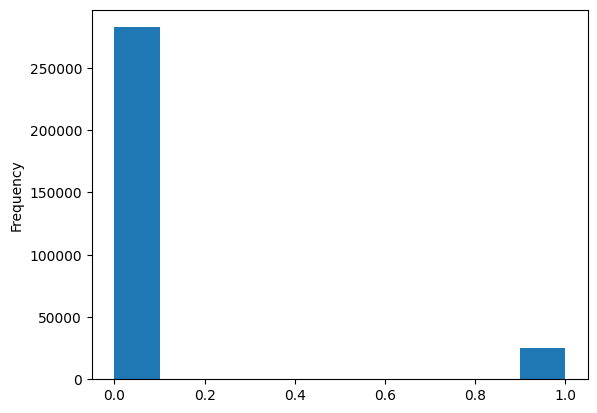

In [19]:
app_train['TARGET'].astype(int).plot.hist()

We found the training dataset very imbalanced.

## 2.2 Input Data Transformation

In [20]:
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [21]:
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

We need to encode categorical features. In this study, we will apply label encoding for categorical features > 2 classes and one-host encoding for binary features.

In [22]:
# LabelEncoder 是 Scikit-learn 提供的一种工具，用于将目标变量（即分类任务中的标签）从离散的类别型数据转换为模型可识别的数值格式。
from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:   #特征小于等于2
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [23]:
# one-hot encoding of categorical variables
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


Align features in training and testing data.

In [24]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


## 2.3 Detect and Impute Missing Values

In [25]:
# Function to calculate missing values by column
def missing_values_table(df):
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    'Percentage of Total Values', ascending=False).round(1)

    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.")

    # Return the dataframe with missing information
    return mis_val_table_ren_columns

For features with <= 20% missing values, it may be due to mistakes in data preparation and the remaining distribution should still be informative. Therefore, we will impute them with median.

For other features with missing values > 20%, we have two options, either to simply drop them or to impute them and add another "missing" indicator. We decided to print out these features and interpret them first.

In [26]:
missing_value_features = missing_values_table(app_train)

print(len(missing_value_features[missing_value_features['Percentage of Total Values'] <= 20]), "has <=20% missing values")
missing_value_features[missing_value_features['Percentage of Total Values'] > 20]

Your selected dataframe has 240 columns.
There are 61 columns that have missing values.
16 has <=20% missing values


,Missing Values,Percentage of Total Values
COMMONAREA_MODE,214865,69.9
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
FLOORSMIN_MEDI,208642,67.8


It turns out that most features here are related to house/appartment area and car ownership (OWN_CAR_AGE). Therefore, a missing value here may indicate that the applicant don't have a car or a place to live, which can potentially say a lot about their ability to pay their loan. It would be dangerous to simply remove them. Instead, the missing pattern itself would be informative. Therefore, we decided to impute these columns with median and add a corresponding missing indicator to preserve such information.

Note that we should impute the test split using the same imputing value from the training dataset and add the same set of missing indicators for feature consistency and to prevent data leakage.

In [27]:
# Iterate through the columns with missing values
for col in missing_value_features.index:
    # If missing values are > 20%, add a binary missing indicator
    if missing_value_features.loc[col, 'Percentage of Total Values'] > 20:
        app_train[f'{col}_MISSING'] = app_train[col].isnull().astype(int)
        app_test[f'{col}_MISSING'] = app_test[col].isnull().astype(int)

    # Impute with median
    median_value = app_train[col].median()
    app_train[col].fillna(median_value, inplace=True)
    app_test[col].fillna(median_value, inplace=True)

In [28]:
print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 285)
Testing Features shape:  (48744, 284)


# 3. Feature Engineering

# 3.3.1 Preliminary Exploratory Data Analysis (EDA) - Highly correlated features

The first step of feature engineering is to do some exploratory data analysis such as correlation to see it there're any particularly important features that can potentially be used in manual feature engineering. It may worth paying attention to them when constructing, for example, polynomial features, with the hope that combining these strong predictor will reveal the interaction among them, subsequently exploit their importance to the task, and explore the complicacy of the feature distribution in the dataset.

In [29]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 DAYS_REGISTRATION                                    0.041975
OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

In the following, we will analyze the most positively (i.e. `DAYS_BIRTH`) and the most negatively correlated features. Note that three mysterious features named "EXT_SOURCE_x" are all (relatively) strongly correlated with the target. Based on `HomeCredit_columns_description.csv`, we were told that they are "Normalized score from external data source", which could be client credit databases. Without knowing what they actually mean, we decided to analyze all three instead of only `EXT_SOURCE_2` to see, for example, their intra-correlation is also high.

### A peek into `DAYS_BIRTH`

In [33]:
app_train['DAYS_BIRTH'].max()

np.int64(-7489)

By peeking into `DAYS_BIRTH`, we found this feature is strangely all negative. Base on the description, this is "Client's age in days at the time of application" so it makes sense to be negative as it's retrospective. However, for interpretability concern, here we will transform them into positive values.

In [44]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_test['DAYS_BIRTH'] = abs(app_test['DAYS_BIRTH'])

app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07823930830982488)

As customers age, there is a negative correlation with the target (indicator of paying difficulties), meaning that the older the client, the more likely they repay their loans on time. This makes sense as younger clients are still at the beginning of their careers and are less likely to have a highly paid positions, which are usually senior positions, secured. Of course, the correlation is not significant (only -0.078). However, since this is the top most feature and is also interpretable, we think it's still necessary to take this correlation into account when we engineer, say, polynomial features.

### Correlating the most correlated features
Including `DAYS_BIRTH`, `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`.

Before constructing polynomial features, we should make sure the features used are not by themselves highly correlated. Otherwise, it will introduce redundancy to the model instead of capturing the complicated interaction between them.

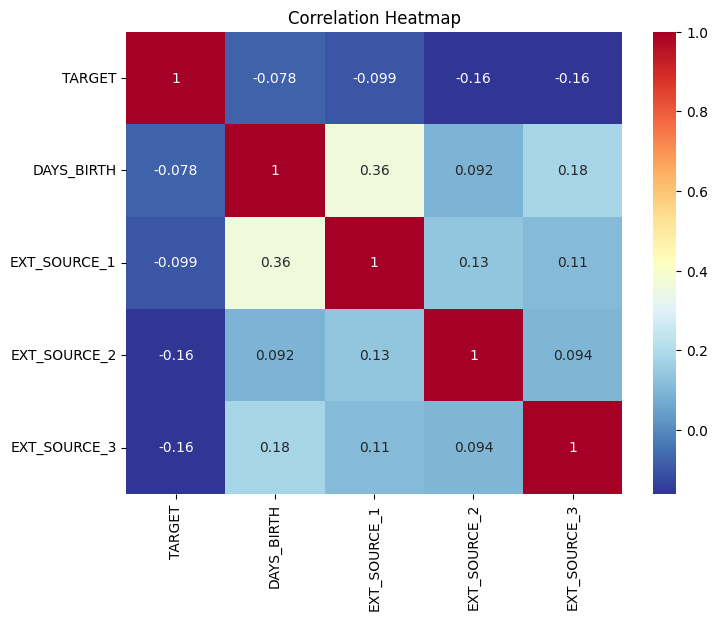

In [75]:
ext_data = app_train[['TARGET', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
ext_data_corrs = ext_data.corr()

plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, annot = True)
plt.title('Correlation Heatmap')
plt.show()

It seems that we are at a safe zone. Note that `EXT_SOURCE_1` and `DAYS_BIRTH` have relatively higher correlation, indicating that age may be one of the scoring factors in that external database. However, since it's at the level of 0.36, we still considered them when we do polynomial features.

# 3.3.2 Manual Feature Engineering

Unlike more complicated tasks such as naturalistic image recognition, where neural nets become powerful and hyperparameter tuning is important, for this type of finance data classification task, where the features are structured and even interpretable, the classification success usually stems from a better feature set instead of a more powerful (and potentially more complicated) model. Feature engineering, in turn, is very important.

Here we will start from manual feature engineering. We first use the best predictors identified in 3.3.1 to construct polynomial features to exploit their intricate interactions. Then, we use domain knowledge (to be honest just our common sense and intuition) to construct domain knowledge features.

### Polynomial Features

In [77]:
# Make a new dataframe for polynomial features
poly_features = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

poly_target = poly_features['TARGET']
poly_features = poly_features.drop(columns = ['TARGET'])

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307511, 35)


And to check the name of newly created features:

In [78]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2', 'EXT_SOURCE_1^3',
       'EXT_SOURCE_1^2 EXT_SOURCE_2', 'EXT_SOURCE_1^2 EXT_SOURCE_3',
       'EXT_SOURCE_1^2 DAYS_BIRTH', 'EXT_SOURCE_1 EXT_SOURCE_2^2',
       'EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH',
       'EXT_SOURCE_1 EXT_SOURCE_3^2',
       'EXT_SOURCE_1 EXT_SOURCE_3 DAYS_BIRTH',
       'EXT_SOURCE_1 DAYS_BIRTH^2', 'EXT_SOURCE_2^3',
       'EXT_SOURCE_2^2 EXT_SOURCE_3', 'EXT_SOURCE_2^2 DAYS_BIRTH',
       'EXT_SOURCE_2 EXT_SOURCE_3^2',
       'EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH',
       'EXT_SOURCE_2 DAYS_BIRTH^2', 'EXT_SOURCE_3^3',
       'EXT_SOURCE_3^2 DAYS_BIRTH', 'EXT_SOURCE_3 DAYS_BIR

And to check whether the new polynomial features constructed are indeed informative (i.e. high correlation with the target.)

In [82]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(poly_features, 
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                         'EXT_SOURCE_3', 'DAYS_BIRTH']))
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))
# Add in the target
poly_features['TARGET'] = poly_target

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(5))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181283
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
Name: TARGET, dtype: float64
DAYS_BIRTH     -0.078239
DAYS_BIRTH^2   -0.076672
DAYS_BIRTH^3   -0.074273
TARGET          1.000000
1                    NaN
Name: TARGET, dtype: float64


Prepare dataframes with these polynomial features incorperated. We will compare model's performance with and without these additional features

In [ ]:
# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = app_train['SK_ID_CURR']
app_train_poly = app_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = app_test['SK_ID_CURR']
app_test_poly = app_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
app_train_poly, app_test_poly = app_train_poly.align(app_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', app_train_poly.shape)
print('Testing data with polynomial features shape:  ', app_test_poly.shape)

Training data with polynomial features shape:  (307511, 275)
Testing data with polynomial features shape:   (48744, 275)


### Domain Knowledge Features

- CREDIT_INCOME_PERCENT：信贷金额占客户收入的百分比
- ANNUITY_INCOME_PERCENT：贷款年金占客户收入的百分比
- CREDIT_TERM：还款期限（月数）（由于年金是每月应付金额）
- DAYS_EMPLOYED_PERCENT：在职天数占客户年龄的百分比

In [ ]:
app_train_domain = app_train.copy()
app_test_domain = app_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYED'] / app_test_domain['DAYS_BIRTH']

plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # matplotlib.pyplot.legend
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html
    plt.legend()
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density')
    
plt.tight_layout(h_pad = 2.5)

In [83]:
def get_balance_data():
    pos_dtype = {
        'SK_ID_PREV':np.uint32, 'SK_ID_CURR':np.uint32, 'MONTHS_BALANCE':np.int32, 'SK_DPD':np.int32,
        'SK_DPD_DEF':np.int32, 'CNT_INSTALMENT':np.float32,'CNT_INSTALMENT_FUTURE':np.float32
    }

    install_dtype = {
        'SK_ID_PREV':np.uint32, 'SK_ID_CURR':np.uint32, 'NUM_INSTALMENT_NUMBER':np.int32, 'NUM_INSTALMENT_VERSION':np.float32, 'DAYS_INSTALMENT':np.float32, 'DAYS_ENTRY_PAYMENT':np.float32, 'AMT_INSTALMENT':np.float32, 'AMT_PAYMENT':np.float32
    }

    card_dtype = {
        'SK_ID_PREV':np.uint32, 'SK_ID_CURR':np.uint32, 'MONTHS_BALANCE':np.int16,
        'AMT_CREDIT_LIMIT_ACTUAL':np.int32, 'CNT_DRAWINGS_CURRENT':np.int32, 'SK_DPD':np.int32,'SK_DPD_DEF':np.int32,
        'AMT_BALANCE':np.float32, 'AMT_DRAWINGS_ATM_CURRENT':np.float32, 'AMT_DRAWINGS_CURRENT':np.float32,
        'AMT_DRAWINGS_OTHER_CURRENT':np.float32, 'AMT_DRAWINGS_POS_CURRENT':np.float32, 'AMT_INST_MIN_REGULARITY':np.float32,
        'AMT_PAYMENT_CURRENT':np.float32, 'AMT_PAYMENT_TOTAL_CURRENT':np.float32, 'AMT_RECEIVABLE_PRINCIPAL':np.float32,
        'AMT_RECIVABLE':np.float32, 'AMT_TOTAL_RECEIVABLE':np.float32, 'CNT_DRAWINGS_ATM_CURRENT':np.float32,
        'CNT_DRAWINGS_OTHER_CURRENT':np.float32, 'CNT_DRAWINGS_POS_CURRENT':np.float32, 'CNT_INSTALMENT_MATURE_CUM':np.float32
    }

    pos_bal = pd.read_csv(os.path.join(default_dir,'POS_CASH_balance.csv'), dtype=pos_dtype)
    install = pd.read_csv(os.path.join(default_dir,'installments_payments.csv'), dtype=install_dtype)
    card_bal = pd.read_csv(os.path.join(default_dir, 'credit_card_balance.csv'), dtype=card_dtype)

    return pos_bal, install, card_bal

def get_apps_processed(apps):
    """
    feature engineering for apps
    """

    # 1.EXT_SOURCE_X FEATURE 
    apps['APPS_EXT_SOURCE_MEAN'] = apps[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis = 1)
    apps['APPS_EXT_SOURCE_STD'] = apps[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    apps['APPS_EXT_SOURCE_STD'] = apps['APPS_EXT_SOURCE_STD'].fillna(apps['APPS_EXT_SOURCE_STD'].mean())
    
    # AMT_CREDIT 
    apps['APPS_ANNUITY_CREDIT_RATIO'] = apps['AMT_ANNUITY']/apps['AMT_CREDIT']
    apps['APPS_GOODS_CREDIT_RATIO'] = apps['AMT_GOODS_PRICE']/apps['AMT_CREDIT']
    
    # AMT_INCOME_TOTAL 
    apps['APPS_ANNUITY_INCOME_RATIO'] = apps['AMT_ANNUITY']/apps['AMT_INCOME_TOTAL']
    apps['APPS_CREDIT_INCOME_RATIO'] = apps['AMT_CREDIT']/apps['AMT_INCOME_TOTAL']
    apps['APPS_GOODS_INCOME_RATIO'] = apps['AMT_GOODS_PRICE']/apps['AMT_INCOME_TOTAL']
    apps['APPS_CNT_FAM_INCOME_RATIO'] = apps['AMT_INCOME_TOTAL']/apps['CNT_FAM_MEMBERS']
    
    # DAYS_BIRTH, DAYS_EMPLOYED 
    apps['APPS_EMPLOYED_BIRTH_RATIO'] = apps['DAYS_EMPLOYED']/apps['DAYS_BIRTH']
    apps['APPS_INCOME_EMPLOYED_RATIO'] = apps['AMT_INCOME_TOTAL']/apps['DAYS_EMPLOYED']
    apps['APPS_INCOME_BIRTH_RATIO'] = apps['AMT_INCOME_TOTAL']/apps['DAYS_BIRTH']
    apps['APPS_CAR_BIRTH_RATIO'] = apps['OWN_CAR_AGE'] / apps['DAYS_BIRTH']
    apps['APPS_CAR_EMPLOYED_RATIO'] = apps['OWN_CAR_AGE'] / apps['DAYS_EMPLOYED']
    
    return apps

In [84]:
def get_prev_processed(prev):
    """
    feature engineering 
    for previouse application credit history
    """
    prev['PREV_CREDIT_DIFF'] = prev['AMT_APPLICATION'] - prev['AMT_CREDIT']
    prev['PREV_GOODS_DIFF'] = prev['AMT_APPLICATION'] - prev['AMT_GOODS_PRICE']
    prev['PREV_CREDIT_APPL_RATIO'] = prev['AMT_CREDIT']/prev['AMT_APPLICATION']
    # prev['PREV_ANNUITY_APPL_RATIO'] = prev['AMT_ANNUITY']/prev['AMT_APPLICATION']
    prev['PREV_GOODS_APPL_RATIO'] = prev['AMT_GOODS_PRICE']/prev['AMT_APPLICATION']

    # Data Cleansing
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)

    # substraction between DAYS_LAST_DUE_1ST_VERSION and DAYS_LAST_DUE
    prev['PREV_DAYS_LAST_DUE_DIFF'] = prev['DAYS_LAST_DUE_1ST_VERSION'] - prev['DAYS_LAST_DUE']

    # 1.Calculate the interest rate
    all_pay = prev['AMT_ANNUITY'] * prev['CNT_PAYMENT']
    prev['PREV_INTERESTS_RATE'] = (all_pay/prev['AMT_CREDIT'] - 1)/prev['CNT_PAYMENT']

    return prev

def get_prev_amt_agg(prev):
    """
    feature engineering for the previous credit appliction
    """

    agg_dict = {
      'SK_ID_CURR':['count'],
      'AMT_CREDIT':['mean', 'max', 'sum'],
      'AMT_ANNUITY':['mean', 'max', 'sum'], 
      'AMT_APPLICATION':['mean', 'max', 'sum'],
      'AMT_DOWN_PAYMENT':['mean', 'max', 'sum'],
      'AMT_GOODS_PRICE':['mean', 'max', 'sum'],
      'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
      'DAYS_DECISION': ['min', 'max', 'mean'],
      'CNT_PAYMENT': ['mean', 'sum'],
        
      'PREV_CREDIT_DIFF':['mean', 'max', 'sum'], 
      'PREV_CREDIT_APPL_RATIO':['mean', 'max'],
      'PREV_GOODS_DIFF':['mean', 'max', 'sum'],
      'PREV_GOODS_APPL_RATIO':['mean', 'max'],
      'PREV_DAYS_LAST_DUE_DIFF':['mean', 'max', 'sum'],
      'PREV_INTERESTS_RATE':['mean', 'max']
    }

    prev_group = prev.groupby('SK_ID_CURR')
    prev_amt_agg = prev_group.agg(agg_dict)

    # multi index 
    prev_amt_agg.columns = ["PREV_"+ "_".join(x).upper() for x in prev_amt_agg.columns.ravel()]

    return prev_amt_agg

def get_prev_refused_appr_agg(prev):
    """
    PREV_APPROVED_COUNT : Credit application approved count
    PREV_REFUSED_COUNT :  Credit application refused count
    """
    prev_refused_appr_group = prev[prev['NAME_CONTRACT_STATUS'].isin(['Approved', 'Refused'])].groupby([ 'SK_ID_CURR', 'NAME_CONTRACT_STATUS'])
    # unstack() 
    prev_refused_appr_agg = prev_refused_appr_group['SK_ID_CURR'].count().unstack()

    # rename column 
    prev_refused_appr_agg.columns = ['PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT' ]

    # NaN
    prev_refused_appr_agg = prev_refused_appr_agg.fillna(0)

    return prev_refused_appr_agg


# DAYS_DECISION
def get_prev_days365_agg(prev):
    """
    DAYS_DESCISION means How many days have been take since the previous credit application made.
    Somehow this feature is important.
    """
    cond_days365 = prev['DAYS_DECISION'] > -365
    prev_days365_group = prev[cond_days365].groupby('SK_ID_CURR')
    agg_dict = {
      'SK_ID_CURR':['count'],
      'AMT_CREDIT':['mean', 'max', 'sum'],
      'AMT_ANNUITY':['mean', 'max', 'sum'], 
      'AMT_APPLICATION':['mean', 'max', 'sum'],
      'AMT_DOWN_PAYMENT':['mean', 'max', 'sum'],
      'AMT_GOODS_PRICE':['mean', 'max', 'sum'],
      'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
      'DAYS_DECISION': ['min', 'max', 'mean'],
      'CNT_PAYMENT': ['mean', 'sum'],
      
      'PREV_CREDIT_DIFF':['mean', 'max', 'sum'], 
      'PREV_CREDIT_APPL_RATIO':['mean', 'max'],
      'PREV_GOODS_DIFF':['mean', 'max', 'sum'],
      'PREV_GOODS_APPL_RATIO':['mean', 'max'],
      'PREV_DAYS_LAST_DUE_DIFF':['mean', 'max', 'sum'],
      'PREV_INTERESTS_RATE':['mean', 'max']
    }

    prev_days365_agg = prev_days365_group.agg(agg_dict)

    # multi index 
    prev_days365_agg.columns = ["PREV_D365_"+ "_".join(x).upper() for x in prev_days365_agg.columns.ravel()]

    return prev_days365_agg

def get_prev_agg(prev):
    prev = get_prev_processed(prev)
    prev_amt_agg = get_prev_amt_agg(prev)
    prev_refused_appr_agg = get_prev_refused_appr_agg(prev)
    prev_days365_agg = get_prev_days365_agg(prev)
    
    # prev_amt_agg
    prev_agg = prev_amt_agg.merge(prev_refused_appr_agg, on='SK_ID_CURR', how='left')
    prev_agg = prev_agg.merge(prev_days365_agg, on='SK_ID_CURR', how='left')
    # SK_ID_CURR APPROVED_COUNT REFUSED_COUNT
    prev_agg['PREV_REFUSED_RATIO'] = prev_agg['PREV_REFUSED_COUNT']/prev_agg['PREV_SK_ID_CURR_COUNT']
    prev_agg['PREV_APPROVED_RATIO'] = prev_agg['PREV_APPROVED_COUNT']/prev_agg['PREV_SK_ID_CURR_COUNT']
    # 'PREV_REFUSED_COUNT', 'PREV_APPROVED_COUNT' drop 
    prev_agg = prev_agg.drop(['PREV_REFUSED_COUNT', 'PREV_APPROVED_COUNT'], axis=1)
    
    return prev_agg

In [85]:
import pandas as pd

def get_bureau_processed(bureau):
    """原始信贷数据预处理，生成衍生特征"""
    bureau['BUREAU_ENDDATE_FACT_DIFF'] = bureau['DAYS_CREDIT_ENDDATE'] - bureau['DAYS_ENDDATE_FACT']
    bureau['BUREAU_CREDIT_FACT_DIFF'] = bureau['DAYS_CREDIT'] - bureau['DAYS_ENDDATE_FACT']
    bureau['BUREAU_CREDIT_ENDDATE_DIFF'] = bureau['DAYS_CREDIT'] - bureau['DAYS_CREDIT_ENDDATE']
  
    bureau['BUREAU_CREDIT_DEBT_RATIO'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']
    bureau['BUREAU_CREDIT_DEBT_DIFF'] = bureau['AMT_CREDIT_SUM_DEBT'] - bureau['AMT_CREDIT_SUM']
    
    bureau['BUREAU_IS_DPD'] = bureau['CREDIT_DAY_OVERDUE'].apply(lambda x: 1 if x > 0 else 0)
    bureau['BUREAU_IS_DPD_OVER120'] = bureau['CREDIT_DAY_OVERDUE'].apply(lambda x: 1 if x > 120 else 0)
    
    return bureau

def aggregate_bureau(bureau, filter_condition=None, prefix='BUREAU'):
    """
    通用的bureau数据聚合函数
    
    参数:
        bureau: 预处理后的bureau DataFrame
        filter_condition: 筛选条件（布尔Series），None表示不筛选
        prefix: 聚合特征的前缀名
        
    返回:
        按SK_ID_CURR聚合后的DataFrame
    """
    # 应用筛选条件
    if filter_condition is not None:
        filtered_bureau = bureau[filter_condition].copy()
    else:
        filtered_bureau = bureau.copy()
    
    # 定义聚合字典（所有聚合函数共用）
    agg_dict = {
        'SK_ID_BUREAU': ['count'],
        'DAYS_CREDIT': ['min', 'max', 'mean'],
        'CREDIT_DAY_OVERDUE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_ENDDATE_FACT': ['min', 'max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['max', 'mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean', 'sum'],

        'BUREAU_ENDDATE_FACT_DIFF': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_FACT_DIFF': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_ENDDATE_DIFF': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_DEBT_RATIO': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_DEBT_DIFF': ['min', 'max', 'mean'],
        'BUREAU_IS_DPD': ['mean', 'sum'],
        'BUREAU_IS_DPD_OVER120': ['mean', 'sum']
    }
    
    # 按用户ID分组聚合
    grouped = filtered_bureau.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名
    grouped.columns = [f'{prefix}_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    # 重置索引，将SK_ID_CURR从索引变为列
    return grouped.reset_index()

def get_bureau_bal_agg(bureau, bureau_bal):
    """处理信贷余额月度记录的聚合"""
    # 关联获取用户ID
    bureau_bal = bureau_bal.merge(bureau[['SK_ID_CURR', 'SK_ID_BUREAU']], on='SK_ID_BUREAU', how='left')
    
    # 衍生逾期特征
    bureau_bal['BUREAU_BAL_IS_DPD'] = bureau_bal['STATUS'].apply(lambda x: 1 if x in ['1','2','3','4','5'] else 0)
    bureau_bal['BUREAU_BAL_IS_DPD_OVER120'] = bureau_bal['STATUS'].apply(lambda x: 1 if x == '5' else 0)
    
    # 定义聚合字典
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'MONTHS_BALANCE': ['min', 'max', 'mean'],
        'BUREAU_BAL_IS_DPD': ['mean', 'sum'],
        'BUREAU_BAL_IS_DPD_OVER120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = bureau_bal.groupby('SK_ID_CURR').agg(agg_dict)
    grouped.columns = [f'BUREAU_BAL_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    return grouped.reset_index()

def get_bureau_agg(bureau, bureau_bal):
    """整合所有聚合特征"""
    # 预处理数据
    processed_bureau = get_bureau_processed(bureau)
    
    # 使用通用聚合函数生成各类聚合特征
    bureau_day_amt_agg = aggregate_bureau(processed_bureau, prefix='BUREAU')
    bureau_active_agg = aggregate_bureau(
        processed_bureau, 
        filter_condition=processed_bureau['CREDIT_ACTIVE'] == 'Active',
        prefix='BUREAU_ACT'
    )
    bureau_days750_agg = aggregate_bureau(
        processed_bureau, 
        filter_condition=processed_bureau['DAYS_CREDIT'] > -750,
        prefix='BUREAU_DAYS750'  # 修正了原代码中的命名问题
    )
    
    # 处理余额数据聚合
    bureau_bal_agg = get_bureau_bal_agg(processed_bureau, bureau_bal)
    
    # 合并所有特征
    bureau_agg = bureau_day_amt_agg.merge(bureau_active_agg, on='SK_ID_CURR', how='left')
    bureau_agg = bureau_agg.merge(bureau_bal_agg, on='SK_ID_CURR', how='left')
    bureau_agg = bureau_agg.merge(bureau_days750_agg, on='SK_ID_CURR', how='left')
    
    # 衍生比例特征
    bureau_agg['BUREAU_ACT_IS_DPD_RATIO'] = bureau_agg['BUREAU_ACT_BUREAU_IS_DPD_SUM'] / bureau_agg['BUREAU_SK_ID_BUREAU_COUNT']
    bureau_agg['BUREAU_ACT_IS_DPD_OVER120_RATIO'] = bureau_agg['BUREAU_ACT_BUREAU_IS_DPD_OVER120_SUM'] / bureau_agg['BUREAU_SK_ID_BUREAU_COUNT']
    
    return bureau_agg

以上流程解释：
这段 Python 代码是信贷数据（Bureau 数据）的特征工程处理流程，核心目标是从原始的信贷记录（bureau表）和信贷余额记录（bureau_bal表）中提取、加工特征，最终生成以 “用户 ID（SK_ID_CURR）” 为维度的聚合特征表，用于后续的信贷风险建模（如贷款违约预测）。

In [86]:
import pandas as pd

def process_pos_bal_features(pos_bal):
    """预处理POS余额数据，生成衍生特征"""
    # 生成逾期标记特征（仅保留有用的特征衍生）
    pos_bal['POS_IS_DPD'] = pos_bal['SK_DPD'].apply(lambda x: 1 if x > 0 else 0)
    pos_bal['POS_IS_DPD_UNDER_120'] = pos_bal['SK_DPD'].apply(lambda x: 1 if (x > 0) & (x < 120) else 0)
    pos_bal['POS_IS_DPD_OVER_120'] = pos_bal['SK_DPD'].apply(lambda x: 1 if x >= 120 else 0)
    return pos_bal

def aggregate_pos_data(pos_data, filter_condition=None, prefix='POS'):
    """通用的POS数据聚合函数"""
    # 应用筛选条件
    if filter_condition is not None:
        filtered_data = pos_data[filter_condition].copy()
    else:
        filtered_data = pos_data.copy()
    
    # 定义聚合字典（只定义一次）
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'MONTHS_BALANCE': ['min', 'mean', 'max'],
        'SK_DPD': ['min', 'max', 'mean', 'sum'],
        'CNT_INSTALMENT': ['min', 'max', 'mean', 'sum'],
        'CNT_INSTALMENT_FUTURE': ['min', 'max', 'mean', 'sum'],
        'POS_IS_DPD': ['mean', 'sum'],
        'POS_IS_DPD_UNDER_120': ['mean', 'sum'],
        'POS_IS_DPD_OVER_120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = filtered_data.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名（修复重复前缀问题）
    grouped.columns = [f'{prefix}_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    return grouped.reset_index()

def get_pos_bal_agg(pos_bal):
    """优化后的POS余额聚合函数，消除了冗余代码"""
    # 预处理数据（仅保留必要的特征衍生）
    processed_pos = process_pos_bal_features(pos_bal)
    
    # 使用通用聚合函数进行全量数据聚合
    pos_bal_agg = aggregate_pos_data(processed_pos, prefix='POS')
    
    # 使用通用聚合函数进行近20个月数据聚合
    cond_months = processed_pos['MONTHS_BALANCE'] > -20
    pos_bal_m20_agg = aggregate_pos_data(processed_pos, cond_months, 'POS_M20')
    
    # 合并聚合结果
    pos_bal_agg = pos_bal_agg.merge(pos_bal_m20_agg, on='SK_ID_CURR', how='left')
    
    return pos_bal_agg

以上流程解释：
这段 Python 代码是POS 机分期付款余额数据（pos_bal表）的特征工程处理流程，核心目标是从用户的 POS 机信贷月度记录中提取、衍生逾期行为和分期状态特征，并按 “用户 ID（SK_ID_CURR）” 聚合，最终生成用于信贷风险建模的用户级 POS 信贷特征表。

In [87]:
import pandas as pd

def get_install_processed(install):
    """预处理分期付款数据，生成衍生特征"""
    # 计算还款差异和比例
    install['AMT_DIFF'] = install['AMT_INSTALMENT'] - install['AMT_PAYMENT']
    install['AMT_RATIO'] = (install['AMT_PAYMENT'] + 1) / (install['AMT_INSTALMENT'] + 1)  # +1避免除零
    
    # 计算逾期天数
    install['SK_DPD'] = install['DAYS_ENTRY_PAYMENT'] - install['DAYS_INSTALMENT']
    
    # 生成逾期标记特征
    install['INS_IS_DPD'] = install['SK_DPD'].apply(lambda x: 1 if x > 0 else 0)
    install['INS_IS_DPD_UNDER_120'] = install['SK_DPD'].apply(lambda x: 1 if (x > 0) & (x < 120) else 0)
    install['INS_IS_DPD_OVER_120'] = install['SK_DPD'].apply(lambda x: 1 if x >= 120 else 0)
    
    return install

def aggregate_installments(install, filter_condition=None, prefix='INS'):
    """
    通用的分期付款数据聚合函数
    
    参数:
        install: 预处理后的分期付款DataFrame
        filter_condition: 筛选条件（布尔Series），None表示不筛选
        prefix: 聚合特征的前缀名
        
    返回:
        按SK_ID_CURR聚合后的DataFrame
    """
    # 应用筛选条件
    if filter_condition is not None:
        filtered_install = install[filter_condition].copy()
    else:
        filtered_install = install.copy()
    
    # 定义聚合字典（所有场景共用）
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DAYS_ENTRY_PAYMENT': ['mean', 'max', 'sum'],
        'DAYS_INSTALMENT': ['mean', 'max', 'sum'],
        'AMT_INSTALMENT': ['mean', 'max', 'sum'],
        'AMT_PAYMENT': ['mean', 'max', 'sum'],
        'AMT_DIFF': ['mean', 'min', 'max', 'sum'],
        'AMT_RATIO': ['mean', 'max'],
        'SK_DPD': ['mean', 'min', 'max'],
        'INS_IS_DPD': ['mean', 'sum'],
        'INS_IS_DPD_UNDER_120': ['mean', 'sum'],
        'INS_IS_DPD_OVER_120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = filtered_install.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名（修复原代码中重复前缀的问题）
    grouped.columns = [f'{prefix}_' + '_'.join(col).upper() for col in grouped.columns.ravel()]
    
    # 重置索引
    return grouped.reset_index()

def get_install_agg(install):
    """整合所有分期付款数据的最终聚合函数"""
    # 预处理数据
    processed_install = get_install_processed(install)
    
    # 使用通用聚合函数生成特征
    # 1. 全量数据聚合
    install_agg = aggregate_installments(processed_install, prefix='INS')
    
    # 2. 近365天数据聚合
    cond_day = processed_install['DAYS_ENTRY_PAYMENT'] >= -365
    install_d365_agg = aggregate_installments(
        processed_install, 
        filter_condition=cond_day, 
        prefix='INS_D365'
    )
    
    # 合并聚合结果
    install_agg = install_agg.merge(install_d365_agg, on='SK_ID_CURR', how='left')
    
    return install_agg

以上流程解释：
这段代码是对分期付款记录数据（install表）的特征工程处理，核心目的是从用户的分期付款记录中提取还款行为、逾期状态等特征，并按用户 ID（SK_ID_CURR）聚合，生成用于信贷风险评估的用户级分期付款特征表。

In [88]:
import pandas as pd

def process_card_bal_features(card_bal):
    """预处理信用卡数据，生成衍生特征"""
    # 避免除以0的风险（当额度为0时用1替代）
    limit = card_bal['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, 1)
    
    # 计算额度使用比例特征
    card_bal['BALANCE_LIMIT_RATIO'] = card_bal['AMT_BALANCE'] / limit
    card_bal['DRAWING_LIMIT_RATIO'] = card_bal['AMT_DRAWINGS_CURRENT'] / limit
    
    # 生成逾期标记特征
    card_bal['CARD_IS_DPD'] = card_bal['SK_DPD'].apply(lambda x: 1 if x > 0 else 0)
    card_bal['CARD_IS_DPD_UNDER_120'] = card_bal['SK_DPD'].apply(
        lambda x: 1 if (x > 0) & (x < 120) else 0
    )
    card_bal['CARD_IS_DPD_OVER_120'] = card_bal['SK_DPD'].apply(
        lambda x: 1 if x >= 120 else 0
    )
    
    return card_bal

def aggregate_card_data(card_data, filter_condition=None, prefix='CARD'):
    """通用的信用卡数据聚合函数"""
    # 应用筛选条件
    if filter_condition is not None:
        filtered_data = card_data[filter_condition].copy()
    else:
        filtered_data = card_data.copy()
    
    # 聚合字典（只定义一次，所有场景共用）
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'AMT_BALANCE': ['max'],
        'AMT_CREDIT_LIMIT_ACTUAL': ['max'],
        'AMT_DRAWINGS_ATM_CURRENT': ['max', 'sum'],
        'AMT_DRAWINGS_CURRENT': ['max', 'sum'],
        'AMT_DRAWINGS_POS_CURRENT': ['max', 'sum'],
        'AMT_INST_MIN_REGULARITY': ['max', 'mean'],
        'AMT_PAYMENT_TOTAL_CURRENT': ['max', 'sum'],
        'AMT_TOTAL_RECEIVABLE': ['max', 'mean'],
        'CNT_DRAWINGS_ATM_CURRENT': ['max', 'sum'],
        'CNT_DRAWINGS_CURRENT': ['max', 'mean', 'sum'],
        'CNT_DRAWINGS_POS_CURRENT': ['mean'],
        'SK_DPD': ['mean', 'max', 'sum'],
        'BALANCE_LIMIT_RATIO': ['min', 'max'],
        'DRAWING_LIMIT_RATIO': ['min', 'max'],
        'CARD_IS_DPD': ['mean', 'sum'],
        'CARD_IS_DPD_UNDER_120': ['mean', 'sum'],
        'CARD_IS_DPD_OVER_120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = filtered_data.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名（修复重复前缀问题）
    grouped.columns = [f'{prefix}_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    return grouped.reset_index()

def get_card_bal_agg(card_bal):
    """优化后的信用卡余额聚合函数，消除冗余代码"""
    # 预处理数据
    processed_card = process_card_bal_features(card_bal)
    
    # 全量数据聚合
    card_bal_agg = aggregate_card_data(processed_card, prefix='CARD')
    
    # 近3个月数据聚合
    cond_month = processed_card['MONTHS_BALANCE'] >= -3
    card_bal_m3_agg = aggregate_card_data(processed_card, cond_month, 'CARD_M3')
    
    # 合并聚合结果（仅需一次reset_index）
    card_bal_agg = card_bal_agg.merge(card_bal_m3_agg, on='SK_ID_CURR', how='left')
    
    return card_bal_agg

以上流程解释：
这段代码是对信用卡月度余额数据（card_bal表）的特征工程处理流程，核心目标是从用户的信用卡月度使用记录中提取 “额度使用”“消费行为”“逾期状态” 等关键特征，并按用户 ID（SK_ID_CURR）聚合，最终生成用于信贷风险评估的用户级信用卡特征表。

# 3.3.3 Automatic Feature Engineering

## Reload The Original Datasets For Final Training

In [89]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

In [90]:
def get_dataset(app_train_preprocessed, app_test_preprocessed):
    """
    load datasets
    1.app_train_preprocessed - train dataset preprocessed in section 2
    2.app_test_preprocessed - test datasets preprocessed in section 2
    3.apps - concatenated app_train, app_test
    4.pos_bal - POS_CACHE
    5.install - installments_payments
    6.card_bal - Credit Card
    """
    app_train_preprocessed = reduce_mem_usage(app_train_preprocessed)
    app_test_preprocessed = reduce_mem_usage(app_test_preprocessed)
    # we temporarily concatenate the train and test dataset for consistent feature engineering procedures
    # they will be separated later
    apps = pd.concat([app_train_preprocessed, app_test_preprocessed])

    prev = pd.read_csv(os.path.join(default_dir,'previous_application.csv'))
    prev = reduce_mem_usage(prev)
    bureau = pd.read_csv(os.path.join(default_dir,'bureau.csv'))
    bureau = reduce_mem_usage(bureau)
    bureau_bal = pd.read_csv(os.path.join(default_dir,'bureau_balance.csv'))
    bureau_bal = reduce_mem_usage(bureau_bal)

    pos_bal, install, card_bal = get_balance_data()

    return apps, prev, bureau, bureau_bal, pos_bal, install, card_bal

apps, prev, bureau, bureau_bal, pos_bal, install, card_bal = get_dataset(app_train, app_test)

Memory usage after optimization is: 107.34 MB
Decreased by 73.1%
Memory usage after optimization is: 16.97 MB
Decreased by 73.1%
Memory usage after optimization is: 309.01 MB
Decreased by 34.5%
Memory usage after optimization is: 112.95 MB
Decreased by 49.3%
Memory usage after optimization is: 338.46 MB
Decreased by 45.8%


## Datasets Concatenation and Join

In [86]:
# apps prev_agg, bureau_agg, pos_bal_agg, install_agg, card_bal_agg
def get_apps_all_with_all_agg(apps, prev, bureau, bureau_bal, pos_bal, install, card_bal):
    """
    Description :
    1.Data preparation , aggregation 
    2.produce the finalized result
    """
    apps_all =  get_apps_processed(apps)
    prev_agg = get_prev_agg(prev)
    bureau_agg = get_bureau_agg(bureau, bureau_bal)
    pos_bal_agg = get_pos_bal_agg(pos_bal)
    install_agg = get_install_agg(install)
    card_bal_agg = get_card_bal_agg(card_bal)
    print('prev_agg shape:', prev_agg.shape, 'bureau_agg shape:', bureau_agg.shape )
    print('pos_bal_agg shape:', pos_bal_agg.shape, 'install_agg shape:', install_agg.shape, 'card_bal_agg shape:', card_bal_agg.shape)
    print('apps_all before merge shape:', apps_all.shape)

    # Join with apps_all
    apps_all = apps_all.merge(prev_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(bureau_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(pos_bal_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(install_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(card_bal_agg, on='SK_ID_CURR', how='left')

    print('apps_all after merge with all shape:', apps_all.shape)

    return apps_all

# 4. Model (Training and Tuning)

## Training (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range = (0, 1))

if BaselineTraining:
    
    if 'TARGET' in app_train:
        train = app_train.drop(columns = ['TARGET'])
    else:
        train = app_train.copy()

    test = app_test.copy()
    features = list(train.columns)

    scaler.fit(train)
    train = scaler.transform(train)
    test = scaler.transform(test)

    print('Training data shape:', train.shape)
    print('Testing data shape:', test.shape)
    
    if LogisticRegression:

        # Make the model with the specified regularization parameter
        log_reg = LogisticRegression(C = 0.0001)

        # Train on the training data
        log_reg.fit(train, train_labels)

        # Make predictions
        # Make sure to select the second column only
        log_reg_pred = log_reg.predict_proba(test)[:, 1]

        # Submission dataframe
        submit = app_test[['SK_ID_CURR']].copy()
        submit.loc[:, 'TARGET'] = log_reg_pred

        # submit.head()

        # Save the submission to a csv file
        submit.to_csv('log_reg_baseline.csv', index = False)
    
    if RandomForest:

        # Make the random forest classifier
        random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

        # Train on the training data
        random_forest.fit(train, train_labels)

        # Extract feature importances
        feature_importance_values = random_forest.feature_importances_
        feature_importances = pd.DataFrame({'feature': features, 'importance': feature_importance_values})

        # Make predictions on the test data
        predictions = random_forest.predict_proba(test)[:, 1]

        # Make a submission dataframe
        submit = app_test[['SK_ID_CURR']].copy()
        submit.loc[:, 'TARGET'] = predictions

        # submit.head()

        # Save the submission dataframe
        submit.to_csv('random_forest_baseline.csv', index = False)

Training data shape: (307511, 240)
Testing data shape: (48744, 240)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   33.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.5s finished


## Training (Engineered Features Implemented)

In [ ]:
if PolynomialFeaturesTesting:
    poly_features_names = list(app_train_poly.columns)

    poly_features = scaler.fit_transform(poly_features)
    poly_features_test = scaler.transform(poly_features_test)

    random_forest_poly = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

    # Train on the training data
    random_forest_poly.fit(poly_features, train_labels)

    # Make predictions on the test data
    predictions = random_forest_poly.predict_proba(poly_features_test)[:, 1]

    # Make a submission dataframe
    submit = app_test[['SK_ID_CURR']].copy()
    submit.loc[:, 'TARGET'] = predictions

    submit.head()

    # Save the submission dataframe
    submit.to_csv('random_forest_baseline_engineered.csv', index = False)

if DomainFeaturesTesting:
    app_train_domain = app_train_domain.drop(columns = 'TARGET')

    domain_features_names = list(app_train_domain.columns)

    domain_features = app_train_domain
    domain_features_test = app_test_domain

    domain_features = scaler.fit_transform(domain_features)
    domain_features_test = scaler.transform(domain_features_test)

    random_forest_domain = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

    # Train on the training data
    random_forest_domain.fit(domain_features, train_labels)

    # Extract feature importances
    feature_importance_values_domain = random_forest_domain.feature_importances_
    feature_importances_domain = pd.DataFrame({'feature': domain_features_names, 'importance': feature_importance_values_domain})

    # Make predictions on the test data
    predictions = random_forest_domain.predict_proba(domain_features_test)[:, 1]

    # Make a submission dataframe
    submit = app_test[['SK_ID_CURR']].copy()
    submit.loc[:, 'TARGET'] = predictions

    # Save the submission dataframe
    submit.to_csv('random_forest_baseline_domain.csv', index = False)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   37.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.3s finished


## Final Training (LGBM)

In [88]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation

def get_apps_all_train_test(apps_all):
    apps_all_train = apps_all[~apps_all['TARGET'].isnull()]
    apps_all_test = apps_all[apps_all['TARGET'].isnull()]

    apps_all_test = apps_all_test.drop('TARGET', axis=1)
    
    return apps_all_train, apps_all_test

def train_apps_all(apps_all_train):
    ftr_app = apps_all_train.drop(['SK_ID_CURR', 'TARGET'], axis=1)
    target_app = apps_all_train['TARGET']

    train_x, valid_x, train_y, valid_y = train_test_split(ftr_app, target_app, test_size=0.2, random_state=2020)
    print('train shape:', train_x.shape, 'valid shape:', valid_x.shape)
    clf = LGBMClassifier(
                nthread=4,
                n_estimators=2000,
                learning_rate=0.02,
                max_depth = 11,
                num_leaves=58,
                colsample_bytree=0.613,
                subsample=0.708,
                max_bin=407,
                reg_alpha=3.564,
                reg_lambda=4.930,
                min_child_weight= 6,
                min_child_samples=165,
                silent=-1,
                verbose= 100,
                )
    callbacks = [early_stopping(stopping_rounds=200), log_evaluation(period=40)]
    clf.fit(train_x, train_y, eval_set=[(train_x, train_y), (valid_x, valid_y)], eval_metric= 'auc', callbacks=callbacks)
    
    return clf

In [ ]:
# application, previous, bureau, bureau_bal
apps_all = get_apps_all_with_all_agg(apps, prev, bureau, bureau_bal, pos_bal, install, card_bal)
# del apps,prev,bureau,bureau_bal,pos_bal,install,card_bal
gc.collect()

apps_all_train, apps_all_test = get_apps_all_train_test(apps_all)

clf = train_apps_all(apps_all_train)

C:\Users\18807\AppData\Local\Temp\ipykernel_31996\1438099645.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  apps['APPS_EXT_SOURCE_MEAN'] = apps[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis = 1)
C:\Users\18807\AppData\Local\Temp\ipykernel_31996\1438099645.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  apps['APPS_EXT_SOURCE_STD'] = apps[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
C:\Users\18807\AppData\Local\Temp\ipykernel_31996\1438099645.py:12: PerformanceWarning: DataFrame is highly fr

prev_agg shape: (338857, 80) bureau_agg shape: (305811, 149)
pos_bal_agg shape: (337252, 45) install_agg shape: (339587, 59) card_bal_agg shape: (103558, 70)
apps_all before merge shape: (356255, 135)
apps_all after merge with all shape: (356255, 534)
train shape: (246008, 532) valid shape: (61503, 532)
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 19946, number of negative: 226062
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.791073
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.363368
[LightGBM] [Debug] init for col-wise cost 0.107445 seconds, init for row-wise cost 0.645489 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.753827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 145623
[LightGBM] [Info] Number of data points in the train set: 246008, number o

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] 

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

...

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 11
[LightGBM]

In [ ]:
del apps,prev,bureau,bureau_bal,pos_bal,install,card_bal

## Prediction

In [90]:
apps_all_test

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CARD_M3BALANCE_LIMIT_RATIO_MIN,CARD_M3BALANCE_LIMIT_RATIO_MAX,CARD_M3DRAWING_LIMIT_RATIO_MIN,CARD_M3DRAWING_LIMIT_RATIO_MAX,CARD_M3CARD_IS_DPD_MEAN,CARD_M3CARD_IS_DPD_SUM,CARD_M3CARD_IS_DPD_UNDER_120_MEAN,CARD_M3CARD_IS_DPD_UNDER_120_SUM,CARD_M3CARD_IS_DPD_OVER_120_MEAN,CARD_M3CARD_IS_DPD_OVER_120_SUM
307511,100001,0,1,0,0,0,135000.0,568800.0,20560.5,450000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307512,100005,0,0,0,0,0,99000.0,222768.0,17370.0,180000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307513,100013,0,0,1,0,0,202500.0,663264.0,69777.0,630000.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
307514,100028,0,1,0,0,2,315000.0,1575000.0,49018.5,1575000.0,...,0.089875,0.165937,0.066709,0.101438,0.0,0.0,0.0,0.0,0.0,0.0
307515,100038,0,0,1,1,1,180000.0,625500.0,32067.0,625500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356250,456221,0,1,0,0,0,121500.0,412560.0,17473.5,270000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
356251,456222,0,1,0,1,2,157500.0,622413.0,31909.5,495000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
356252,456223,0,1,1,0,1,202500.0,315000.0,33205.5,315000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
356253,456224,0,0,0,1,0,225000.0,450000.0,25128.0,450000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
output_dir = "../output/kaggle/working/"
preds = clf.predict_proba(apps_all_test.drop(['SK_ID_CURR'], axis=1))[:, 1]
apps_all_test['TARGET'] = preds
#apps_all_test[['SK_ID_CURR', 'TARGET']].to_csv(os.path.join(output_dir,'pos_install_credit_02.csv'), index=False)
apps_all_test[['SK_ID_CURR', 'TARGET']]

[LightGBM] [Warning] Unknown parameter: silent


C:\Users\18807\AppData\Local\Temp\ipykernel_31996\4119908899.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  apps_all_test['TARGET'] = preds


,SK_ID_CURR,TARGET
307511,100001,0.034043
307512,100005,0.150499
307513,100013,0.062475
307514,100028,0.037561
307515,100038,0.194965
...,...,...
356250,456221,0.026540
356251,456222,0.045021
356252,456223,0.009200
356253,456224,0.022814


In [92]:
apps_all_test[['SK_ID_CURR', 'TARGET']].to_csv('submission.csv', index=False)

# 5. Interpretation

## Feature Importances (Final)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

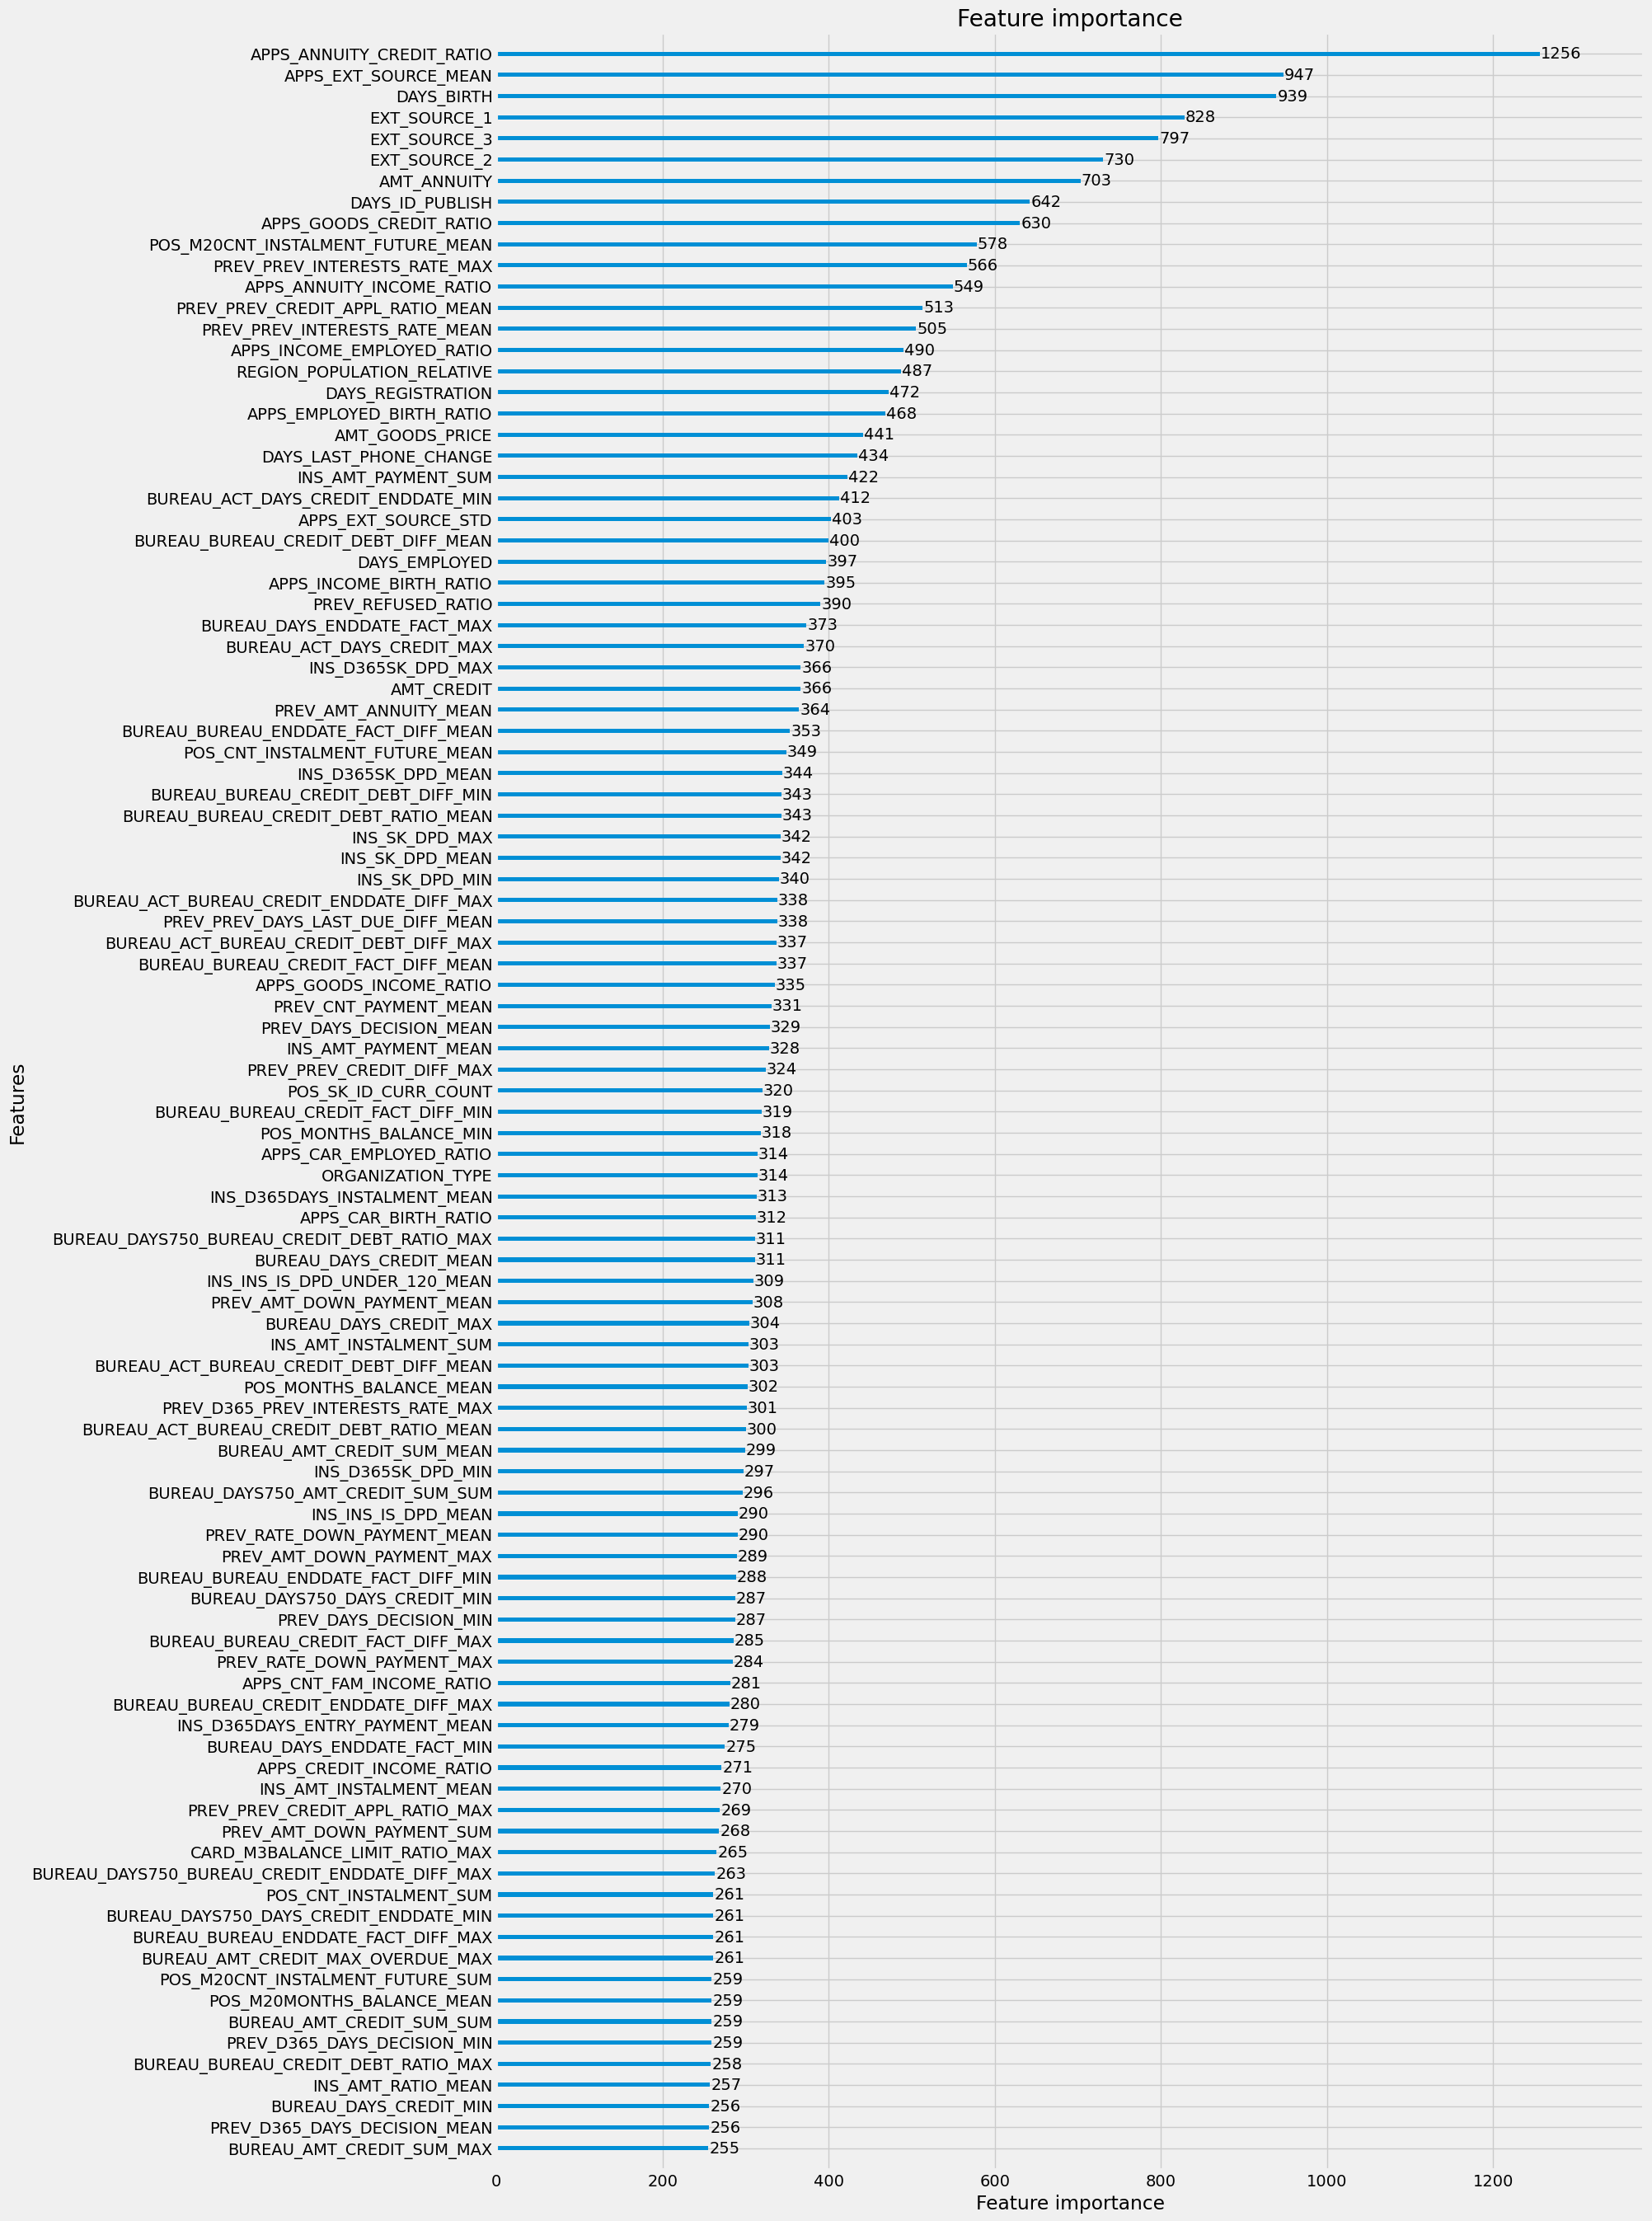

In [93]:
from lightgbm import plot_importance

plot_importance(clf, figsize=(16, 32), max_num_features=100)

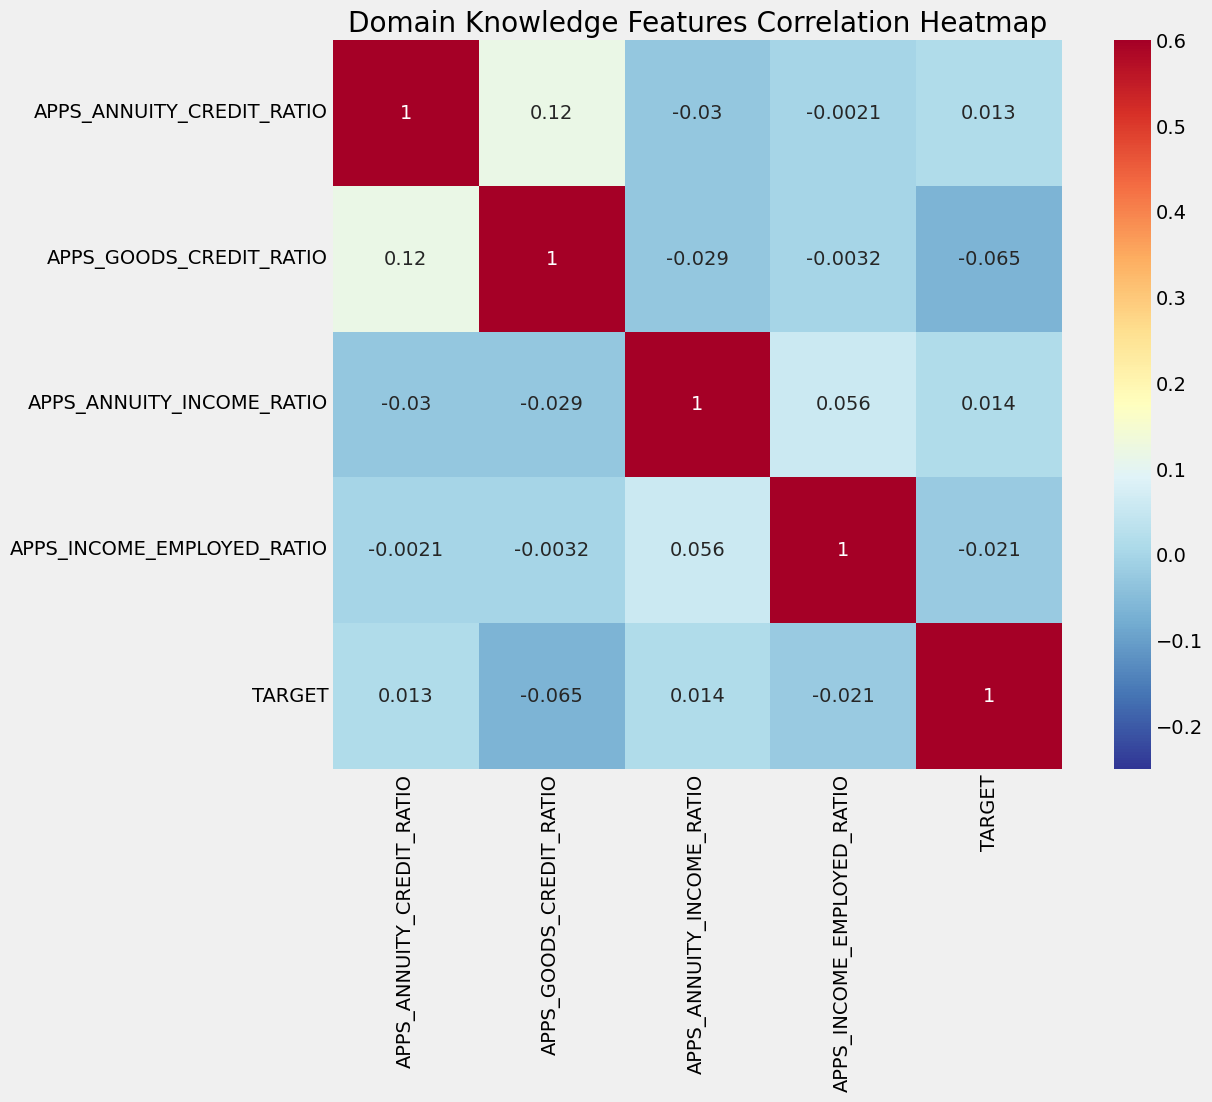

In [95]:
# https://stackoverflow.com/questions/42579908/use-corr-to-get-the-correlation-between-two-columns
Domain_Knowledge_Features_corrs = apps_all_train[['APPS_ANNUITY_CREDIT_RATIO', 'APPS_GOODS_CREDIT_RATIO', 'APPS_ANNUITY_INCOME_RATIO', 'APPS_INCOME_EMPLOYED_RATIO', 'TARGET']].corr()

plt.figure(figsize = (12, 9))

# Heatmap of correlations
sns.heatmap(Domain_Knowledge_Features_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Domain Knowledge Features Correlation Heatmap')

plt.savefig('./Domain Knowledge Features Correlation Heatmap.png', bbox_inches = 'tight')
plt.imshow(plt.imread('./Domain Knowledge Features Correlation Heatmap.png'))

由以上可知，重要特征之间的相关性足够小以保证特征空间能够用多个特征诠释